Cell 1 — Imports

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

2. Create our dataset

In [2]:
x = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])

y = torch.tensor([
    [1.0],
    [4.0],
    [9.0],
    [16.0],
    [25.0]
])

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: torch.Size([5, 1])
y shape: torch.Size([5, 1])


3. Create the MLP

In [3]:
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


4. Check the parameters

In [4]:
for name, param in model.named_parameters():
    print(name, param.shape)

0.weight torch.Size([16, 1])
0.bias torch.Size([16])
2.weight torch.Size([16, 16])
2.bias torch.Size([16])
4.weight torch.Size([1, 16])
4.bias torch.Size([1])


5. Before training — let's see how stupid the network is

In [5]:
with torch.no_grad():
    prediction = model(x)

print(prediction)

tensor([[-0.2072],
        [-0.1962],
        [-0.2029],
        [-0.2158],
        [-0.2293]])


6. Set up training

In [6]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

7. Train it

In [7]:
losses = []
print(f"Epoch 0: Loss = {loss_fn(prediction, y):.6f}")
for epoch in range(5000):

    prediction = model(x)

    loss = loss_fn(prediction, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

Epoch 4500: Loss = 0.000663


8. Visualize the loss

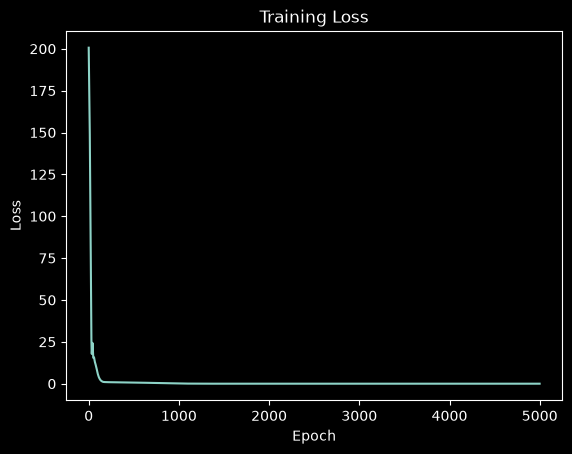

In [8]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

9. Check the predictions

In [9]:
with torch.no_grad():
    prediction = model(x)

for input_value, predicted, actual in zip(x, prediction, y):
    print(
        f"x={input_value.item():.0f} "
        f"predicted={predicted.item():.3f} "
        f"actual={actual.item():.3f}"
    )

x=1 predicted=1.000 actual=1.000
x=2 predicted=4.000 actual=4.000
x=3 predicted=9.000 actual=9.000
x=4 predicted=16.001 actual=16.000
x=5 predicted=25.001 actual=25.000


11. Now let's visualize the function

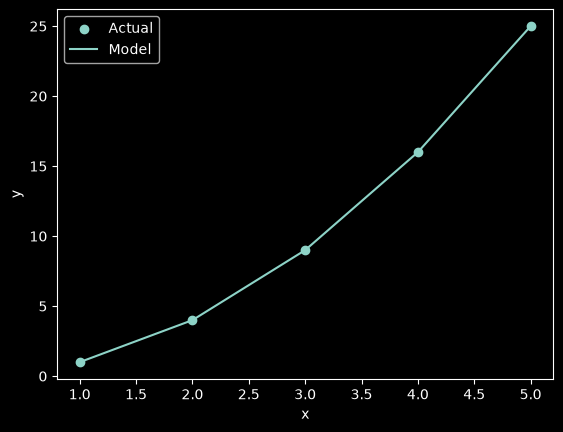

In [10]:
plt.scatter(x.numpy(), y.numpy(), label="Actual")

with torch.no_grad():
    predicted = model(x)

plt.plot(
    x.numpy(),
    predicted.numpy(),
    label="Model"
)

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()